### 1. 데이터 준비

In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/preprocessed/Life_Expectancy_Data_preprocessed.csv')

df.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Iso_code,Region,Schooling
0,Afghanistan,2000,Developing,54.8,321.0,88,0.01,62.0,6532,12.2,122,24.0,24.0,0.1,114.560000,2.3,2.5,AFG,Asia,1.264052
1,Afghanistan,2001,Developing,55.3,316.0,88,0.01,63.0,8762,12.6,122,35.0,33.0,0.1,117.496980,2.1,2.4,AFG,Asia,1.315551
2,Afghanistan,2002,Developing,56.2,3.0,88,0.01,64.0,2486,13.0,122,36.0,36.0,0.1,187.845950,19.9,2.2,AFG,Asia,1.367049
3,Afghanistan,2003,Developing,56.7,295.0,87,0.01,65.0,798,13.4,122,41.0,41.0,0.1,198.728544,19.7,19.9,AFG,Asia,1.418548
4,Afghanistan,2004,Developing,57.0,293.0,87,0.02,67.0,466,13.8,120,5.0,5.0,0.1,219.141353,19.5,19.7,AFG,Asia,1.470046


In [99]:
encoded = [0 if status == 'Developing' else 1 for status in df['Status']]

df['Status'] = encoded
df

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Iso_code,Region,Schooling
0,Afghanistan,2000,0,54.8,321.0,88,0.01,62.0,6532,12.2,122,24.0,24.0,0.1,114.560000,2.3,2.5,AFG,Asia,1.264052
1,Afghanistan,2001,0,55.3,316.0,88,0.01,63.0,8762,12.6,122,35.0,33.0,0.1,117.496980,2.1,2.4,AFG,Asia,1.315551
2,Afghanistan,2002,0,56.2,3.0,88,0.01,64.0,2486,13.0,122,36.0,36.0,0.1,187.845950,19.9,2.2,AFG,Asia,1.367049
3,Afghanistan,2003,0,56.7,295.0,87,0.01,65.0,798,13.4,122,41.0,41.0,0.1,198.728544,19.7,19.9,AFG,Asia,1.418548
4,Afghanistan,2004,0,57.0,293.0,87,0.02,67.0,466,13.8,120,5.0,5.0,0.1,219.141353,19.5,19.7,AFG,Asia,1.470046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2761,Zimbabwe,2011,0,54.9,464.0,28,6.00,94.0,0,29.9,42,93.0,93.0,13.3,839.927936,6.8,6.7,ZWE,Africa,7.768000
2762,Zimbabwe,2012,0,56.6,429.0,26,6.09,97.0,0,3.3,39,95.0,95.0,8.8,955.648466,6.5,6.4,ZWE,Africa,7.870000
2763,Zimbabwe,2013,0,58.0,399.0,25,6.39,95.0,0,3.8,36,95.0,95.0,6.8,111.227396,6.2,6.0,ZWE,Africa,7.990000
2764,Zimbabwe,2014,0,59.2,371.0,23,6.50,91.0,0,31.3,34,92.0,91.0,6.3,127.474620,5.9,5.7,ZWE,Africa,8.110000


### 2. 전체 개요 확인

#### 2.1 기대수명 분포 확인

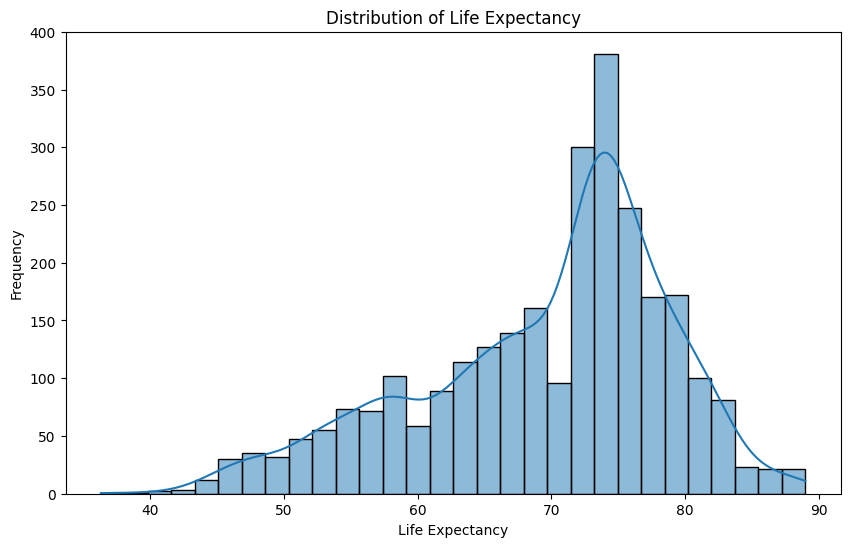

count    2766.000000
mean       69.576511
std         9.379059
min        36.300000
25%        63.900000
50%        72.400000
75%        75.800000
max        89.000000
Name: Life_expectancy, dtype: float64


In [100]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Life_expectancy'], kde=True, bins=30)
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Frequency')
plt.show()

# 기대수명의 기술 통계량
print(df['Life_expectancy'].describe())

#### 2.2 경제 상태별 기대수명 차이 확인

C:\Users\Moon\AppData\Local\Temp\ipykernel_38608\1728774617.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Life_expectancy', palette='pastel')


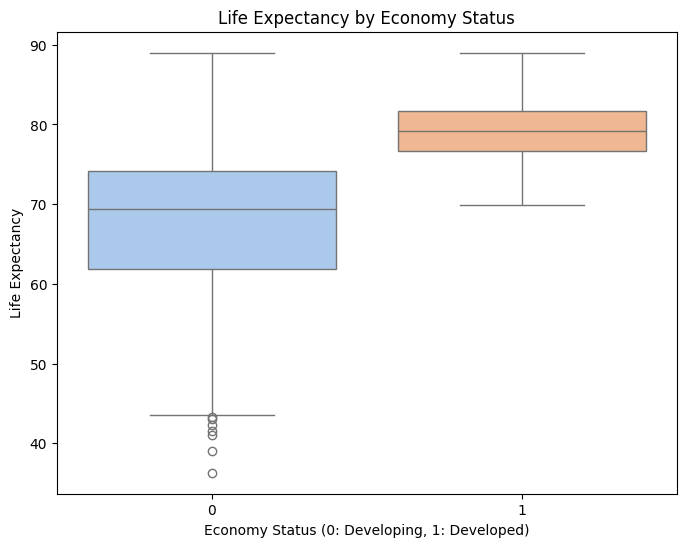

         count       mean       std   min     25%   50%   75%   max
Status                                                             
0       2270.0  67.485476  8.910715  36.3  61.825  69.4  74.1  89.0
1        496.0  79.146371  3.948505  69.9  76.675  79.2  81.7  89.0


In [101]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Status', y='Life_expectancy', palette='pastel')
plt.title('Life Expectancy by Economy Status')
plt.xlabel('Economy Status (0: Developing, 1: Developed)')
plt.ylabel('Life Expectancy')
plt.show()

# 각 경제 상태별 기대수명 통계량 확인
print(df.groupby('Status')['Life_expectancy'].describe())

### 3. 통합 상관관계 분석 (Correlation Analysis)

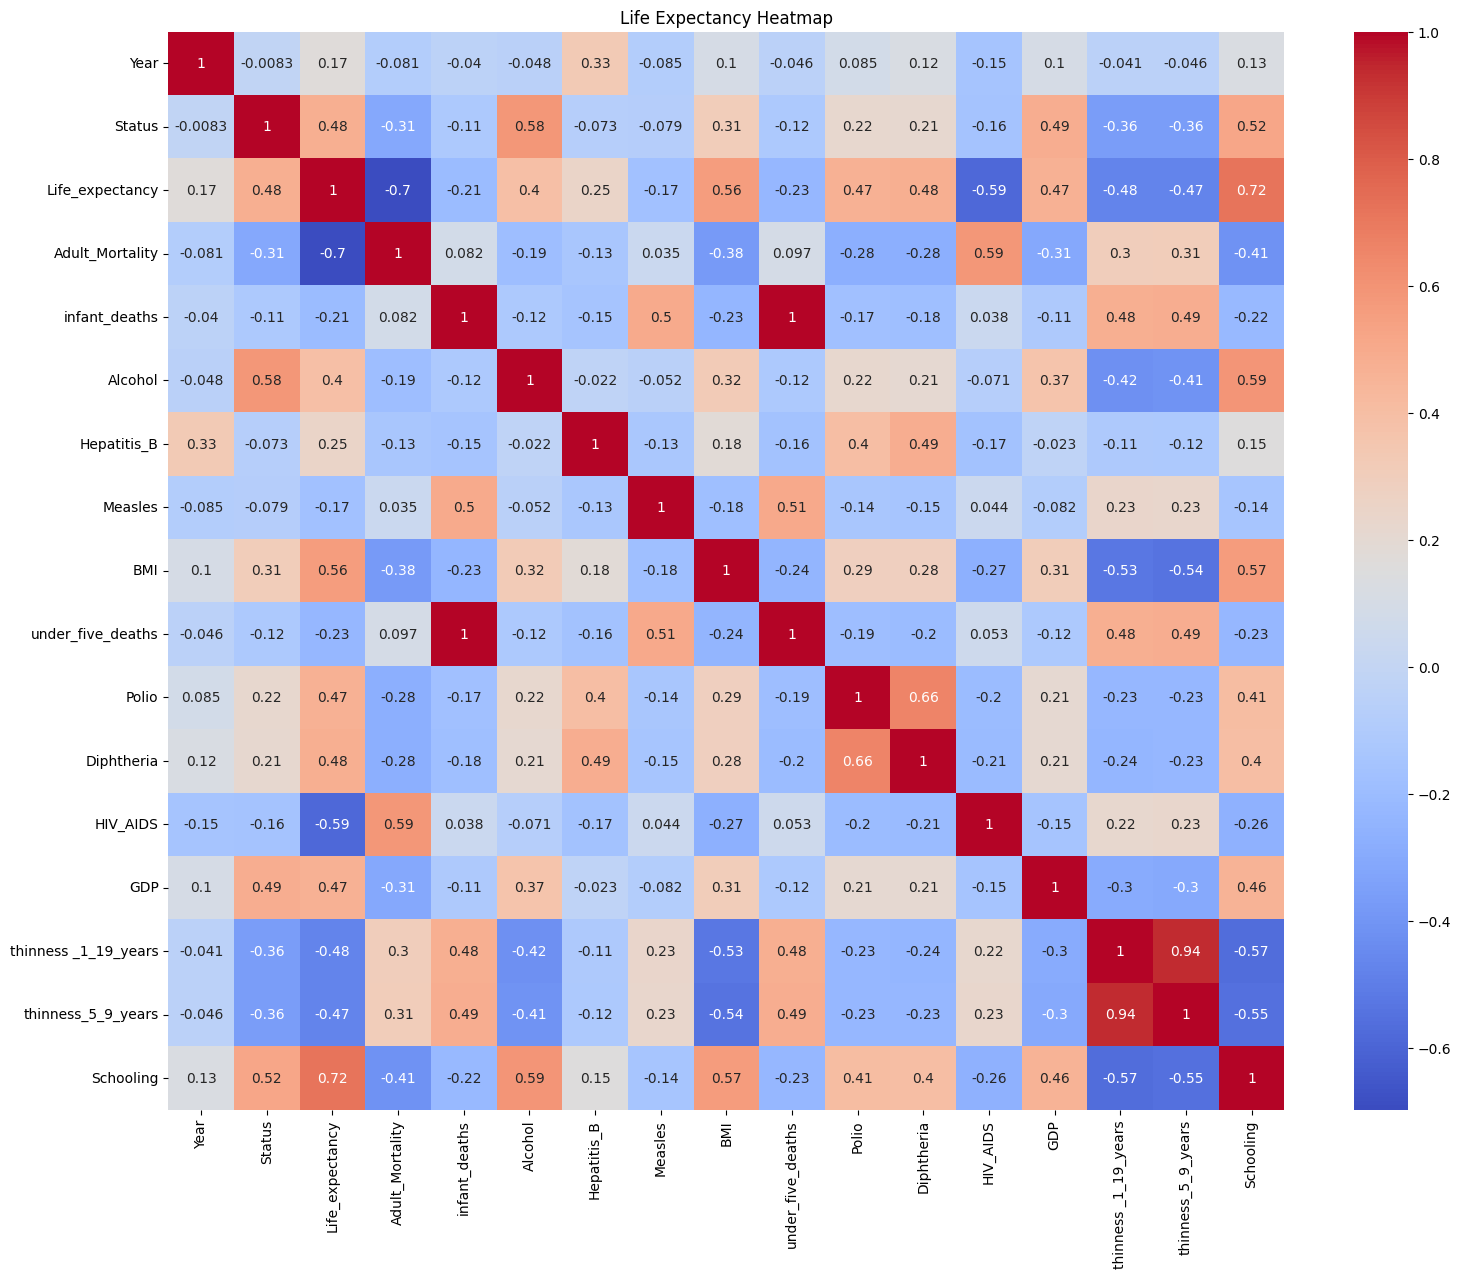

Life_expectancy         1.000000
Schooling               0.721491
BMI                     0.557872
Diphtheria              0.479626
Status                  0.477038
GDP                     0.468797
Polio                   0.467881
Alcohol                 0.396519
Hepatitis_B             0.248192
Year                    0.166027
Measles                -0.167841
infant_deaths          -0.205290
under_five_deaths      -0.230681
thinness_5_9_years     -0.474884
thinness _1_19_years   -0.477864
HIV_AIDS               -0.585710
Adult_Mortality        -0.696681
Name: Life_expectancy, dtype: float64


In [102]:
correlation_matrix = df.corr(numeric_only=True)

# 상관관계 히트맵 시각화
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Life Expectancy Heatmap')
plt.show()


# 기대수명과의 상관관계를 내림차순 정렬
life_expectancy_corr = correlation_matrix['Life_expectancy'].sort_values(ascending=False)
print(life_expectancy_corr)

궁금증: 왜 schooling과 가장 높은 양의 상관관계를 갖는지?  
-> 사회, 경제적 요인이 어쩌면 기대수명에 더 큰 영향을 주나?

### 4. 주요 요인별 심층 분석
상관관계 분석 결과를 바탕으로, 변수들을 아래의 4가지 기준으로 재분류하여 심층 분석을 진행함  
연도와 지역별로 나누어서 보는게 아니라 이러한 요인들이 갖추어진 상황에서 기대수명이 어떻게 바뀌는지 보이고자 함  
단, 비약이 존재하기 때문에 주의할 필요가 있음.

- **그룹 1: 사회경제적 요인**: `Schooling`, `GDP_per_capita`, `Economy_status`
- **그룹 2: 생활/영양 요인**: `Alcohol_consumption`, `BMI`, `Thinness_ten_nineteen_years`, `Thinness_five_nine_years`
- **그룹 3: 질병 및 예방접종 요인**: `Incidents_HIV`, `Hepatitis_B`, `Polio`, `Diphtheria`, `Measles`
- **그룹 4: 보건 결과 지표**: `Adult_mortality`, `Infant_deaths`, `Under_five_deaths`


PCA를 이용해서 각 그룹의 요소들을 대표하는 종합 점수(종합 변수)를 만들어 시각화해 봄

##### 상관관계 양수로 통일
- 나중에 종합점수로 영향력을 계산할 때 어느거는 양수고, 어느거는 음수로 나오면 골치 아플거 같음

In [103]:
# 음의 상관관계를 갖는 지표들 리스트
negative_indicators = [index for index, val in life_expectancy_corr.items() if val < 0]

In [104]:
df_positive = df.copy()

# 방향 반전 및 컬럼명 변경
for col in negative_indicators:
    new_col_name = col + '_Reversed'
    df_positive[new_col_name] = -df[col]
    df.drop(col, axis=1)
    print(f"변환 완료: {col} -> {new_col_name}")

# 3. 이제 긍정 지표들만 모아서 그룹핑 진행
health_outcome_factors = ['Infant_Survival', 'Under_Five_Survival', 'Adult_Survival']
# 예: 영양/생활 종합 점수
nutritional_factors = ['BMI', 'Alcohol_Control_Score', 'Nutritional_Status_10_19', 'Nutritional_Status_5_9']

변환 완료: Measles -> Measles_Reversed
변환 완료: infant_deaths -> infant_deaths_Reversed
변환 완료: under_five_deaths -> under_five_deaths_Reversed
변환 완료: thinness_5_9_years -> thinness_5_9_years_Reversed
변환 완료: thinness _1_19_years -> thinness _1_19_years_Reversed
변환 완료: HIV_AIDS -> HIV_AIDS_Reversed
변환 완료: Adult_Mortality -> Adult_Mortality_Reversed


In [105]:
df.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Iso_code,Region,Schooling
0,Afghanistan,2000,0,54.8,321.0,88,0.01,62.0,6532,12.2,122,24.0,24.0,0.1,114.560000,2.3,2.5,AFG,Asia,1.264052
1,Afghanistan,2001,0,55.3,316.0,88,0.01,63.0,8762,12.6,122,35.0,33.0,0.1,117.496980,2.1,2.4,AFG,Asia,1.315551
2,Afghanistan,2002,0,56.2,3.0,88,0.01,64.0,2486,13.0,122,36.0,36.0,0.1,187.845950,19.9,2.2,AFG,Asia,1.367049
3,Afghanistan,2003,0,56.7,295.0,87,0.01,65.0,798,13.4,122,41.0,41.0,0.1,198.728544,19.7,19.9,AFG,Asia,1.418548
4,Afghanistan,2004,0,57.0,293.0,87,0.02,67.0,466,13.8,120,5.0,5.0,0.1,219.141353,19.5,19.7,AFG,Asia,1.470046


In [106]:
# Standardization 먼저
# 각 column에 따라 값의 범위가 너무 다르기 때문에 scaling을 통해 통일 시켜주고 pca를 계산
from sklearn.preprocessing import StandardScaler

# 숫자 feature들
feature_cols = df_positive.drop(['Country', 'Region', 'Iso_code'], axis=1).columns
df_features = df_positive[feature_cols]

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=feature_cols)

df_scaled['Life_expectancy'] = df_positive['Life_expectancy']

df_scaled.head()

,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,...,thinness _1_19_years,thinness_5_9_years,Schooling,Measles_Reversed,infant_deaths_Reversed,under_five_deaths_Reversed,thinness_5_9_years_Reversed,thinness _1_19_years_Reversed,HIV_AIDS_Reversed,Adult_Mortality_Reversed
0,-1.649378,-0.467442,54.8,1.302581,0.469850,-1.159232,-0.143904,0.344606,-1.319216,0.479598,...,-0.561548,-0.515119,-2.021395,-0.344606,-0.469850,-0.479598,0.515119,0.561548,0.337353,-1.302581
1,-1.431821,-0.467442,55.3,1.261781,0.469850,-1.159232,-0.117414,0.533937,-1.299206,0.479598,...,-0.606871,-0.537344,-2.005665,-0.533937,-0.469850,-0.479598,0.537344,0.606871,0.337353,-1.261781
2,-1.214263,-0.467442,56.2,-1.292276,0.469850,-1.159232,-0.090924,0.001093,-1.279196,0.479598,...,3.426933,-0.581793,-1.989934,-0.001093,-0.469850,-0.479598,0.581793,-3.426933,0.337353,1.292276
3,-0.996706,-0.467442,56.7,1.090422,0.461611,-1.159232,-0.064433,-0.142222,-1.259186,0.479598,...,3.381609,3.351962,-1.974204,0.142222,-0.461611,-0.479598,-3.351962,-3.381609,0.337353,-1.090422
4,-0.779148,-0.467442,57.0,1.074103,0.461611,-1.156764,-0.011452,-0.170409,-1.239176,0.467482,...,3.336285,3.307513,-1.958474,0.170409,-0.461611,-0.467482,-3.307513,-3.336285,0.337353,-1.074103


#### 4.1 사회경제적 요인

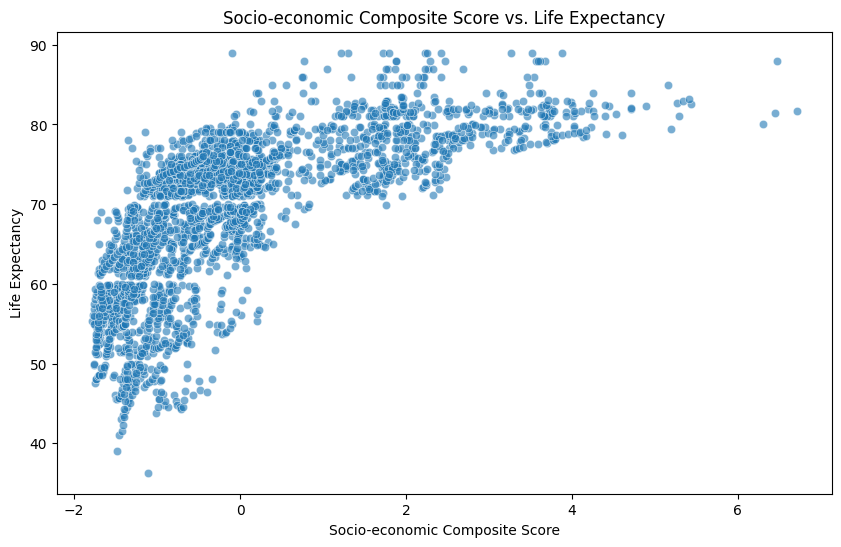

사회경제적 종합 점수와 기대수명과의 상관관계: 0.684728387053826
설명력: 0.66
[[0.57836684 0.56602331 0.58746014]]


In [107]:
from sklearn.decomposition import PCA

socio_economic_factors = ['Schooling', 'GDP', 'Status']
df_socio_economic = df_scaled[socio_economic_factors]

# PCA 실행
pca_socio_economic = PCA(n_components=1)
socio_economic_score = pca_socio_economic.fit_transform(df_socio_economic)

df_scaled['SocioEconomic_Composite'] = socio_economic_score

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_scaled['SocioEconomic_Composite'], y=df_scaled['Life_expectancy'], alpha=0.6)
plt.title('Socio-economic Composite Score vs. Life Expectancy')
plt.xlabel('Socio-economic Composite Score')
plt.ylabel('Life Expectancy')
plt.show()

print(f"사회경제적 종합 점수와 기대수명과의 상관관계: {df_scaled['SocioEconomic_Composite'].corr(df_scaled['Life_expectancy'])}")
print(f"설명력: {pca_socio_economic.explained_variance_ratio_[0]:.2f}")
print(pca_socio_economic.components_)

#### 4.2 생활/영양 요인

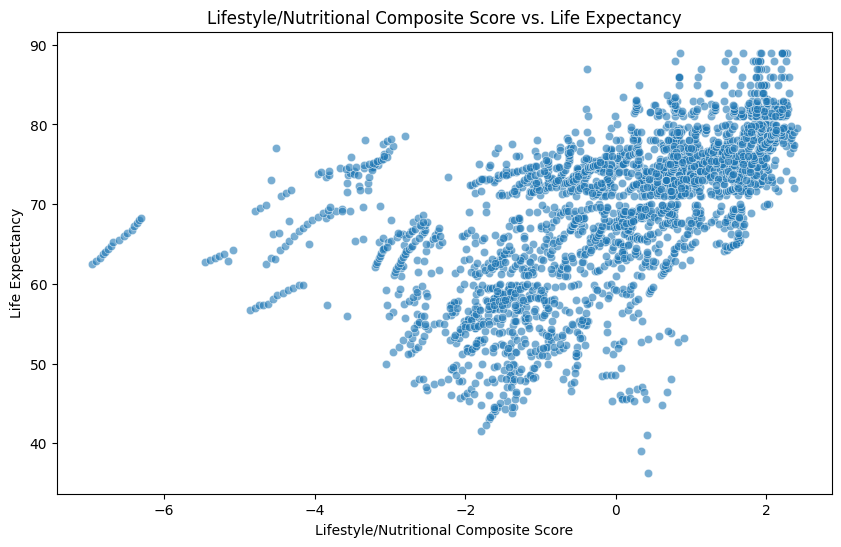

생활/영양 종합 점수와 기대 수명 간의 상관계수: 0.5830086622089793
설명력: 0.66
[[0.37952227 0.44898718 0.57198683 0.57201785]]


In [108]:
nutritional_factors = ['Alcohol', 'BMI', 'thinness _1_19_years_Reversed', 'thinness_5_9_years_Reversed']
df_nutritional = df_scaled[nutritional_factors]

pca_nutritional = PCA(n_components=1)
nutritional_score = pca_nutritional.fit_transform(df_nutritional)

df_scaled['LifestyleNutritional_Composite'] = nutritional_score

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_scaled['LifestyleNutritional_Composite'], y=df_scaled['Life_expectancy'], alpha=0.6)
plt.title('Lifestyle/Nutritional Composite Score vs. Life Expectancy')
plt.xlabel('Lifestyle/Nutritional Composite Score')
plt.ylabel('Life Expectancy')
plt.show()

print(f"생활/영양 종합 점수와 기대 수명 간의 상관계수: {df_scaled['LifestyleNutritional_Composite'].corr(df_scaled['Life_expectancy'])}")
print(f"설명력: {pca_nutritional.explained_variance_ratio_[0]:.2f}")
print(pca_nutritional.components_)

#### 4.3 질병 및 예방접종 요인

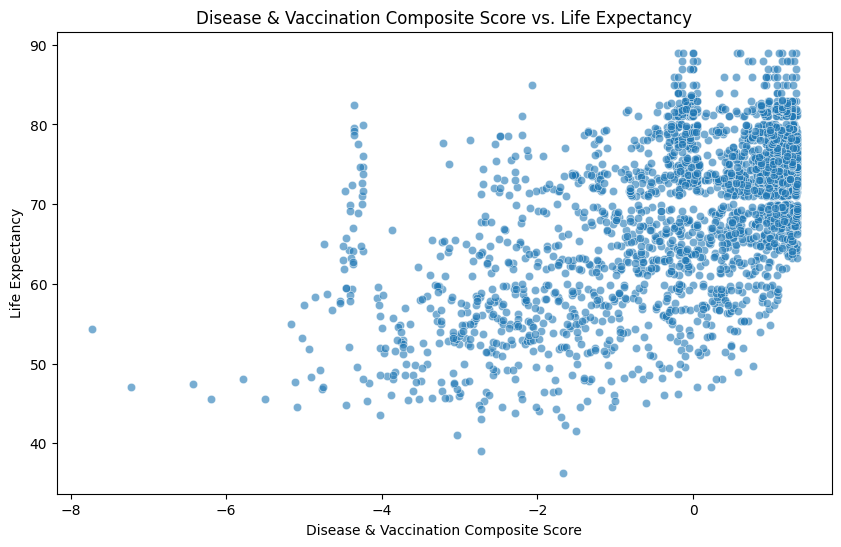

질병/예방접종 종합 점수와 기대수명 간의 상관계수: 0.5770
설명력: 0.44
[[0.27215386 0.48724734 0.55768315 0.58095349 0.20001216]]


In [109]:
disease_vaccination_factors = ['HIV_AIDS_Reversed', 'Hepatitis_B', 'Polio', 'Diphtheria', 'Measles_Reversed']
df_disease = df_scaled[disease_vaccination_factors]

pca_disease = PCA(n_components=1)
disease_score = pca_disease.fit_transform(df_disease)

df_scaled['DiseaseVaccination_Composite'] = disease_score

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_scaled['DiseaseVaccination_Composite'], y=df_scaled['Life_expectancy'], alpha=0.6)
plt.title('Disease & Vaccination Composite Score vs. Life Expectancy')
plt.xlabel('Disease & Vaccination Composite Score')
plt.ylabel('Life Expectancy')
plt.show()

print(f"질병/예방접종 종합 점수와 기대수명 간의 상관계수: {df_scaled['DiseaseVaccination_Composite'].corr(df_scaled['Life_expectancy']):.4f}")
print(f"설명력: {pca_disease.explained_variance_ratio_[0]:.2f}")
print(pca_disease.components_)

#### 4.4 보건 결과 지표
- 이 부분은 너무 뻔한 결과긴 함.. 걍 뺄까?

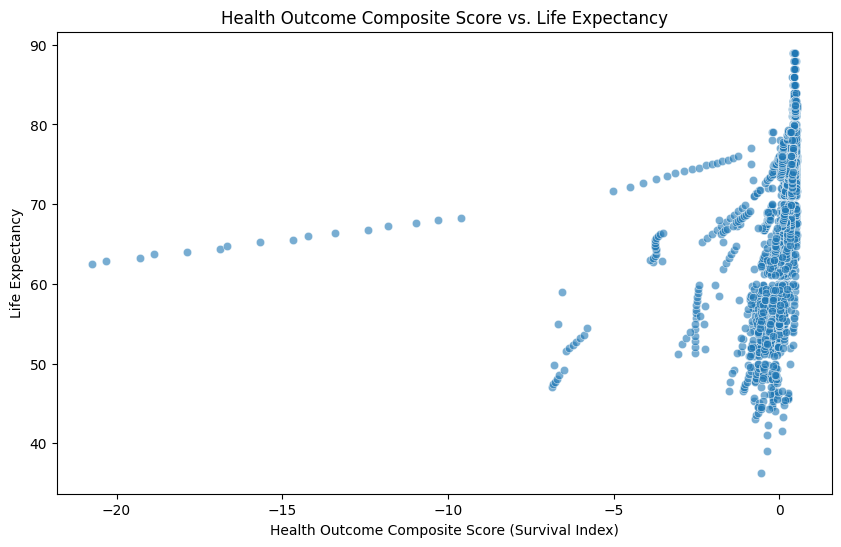

보건 결과 종합 점수와 기대수명 간의 상관계수: 0.2764
설명력: 0.67
[[0.123723   0.70122171 0.70212587]]


In [110]:
health_outcome_factors = ['Adult_Mortality_Reversed', 'infant_deaths_Reversed', 'under_five_deaths_Reversed']
df_outcome = df_scaled[health_outcome_factors]

pca_outcome = PCA(n_components=1)
outcome_score = pca_outcome.fit_transform(df_outcome)

df_scaled['HealthOutcome_Composite'] = outcome_score

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_scaled['HealthOutcome_Composite'], y=df_scaled['Life_expectancy'], alpha=0.6)
plt.title('Health Outcome Composite Score vs. Life Expectancy')
plt.xlabel('Health Outcome Composite Score (Survival Index)')
plt.ylabel('Life Expectancy')
plt.show()

print(f"보건 결과 종합 점수와 기대수명 간의 상관계수: {df_scaled['HealthOutcome_Composite'].corr(df_scaled['Life_expectancy']):.4f}")
print(f"설명력: {pca_outcome.explained_variance_ratio_[0]:.2f}")
print(pca_outcome.components_)

---

### 5. 최종 결론 (Conclusion)

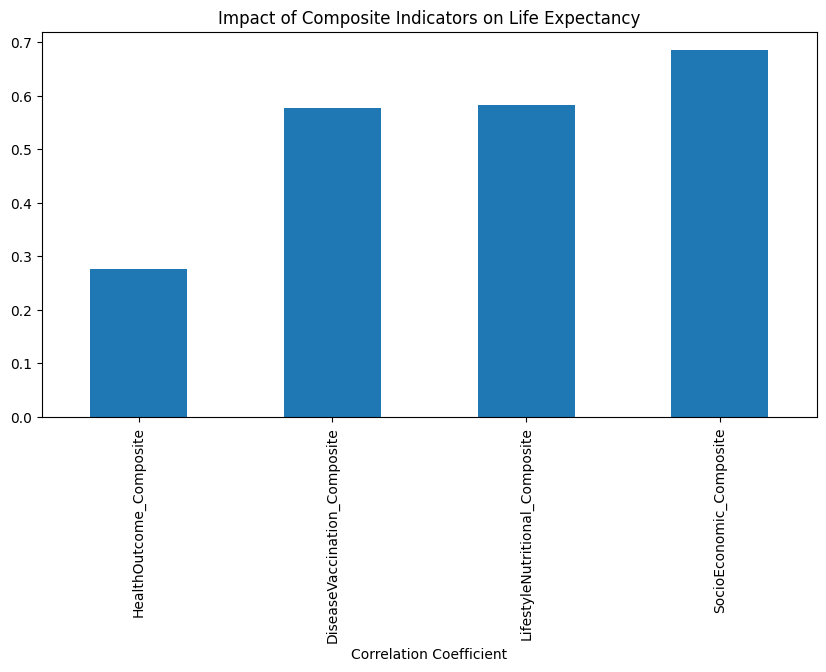

In [111]:
composites = ['SocioEconomic_Composite', 'LifestyleNutritional_Composite', 'DiseaseVaccination_Composite', 'HealthOutcome_Composite']
correlations = df_scaled[composites + ['Life_expectancy']].corr()['Life_expectancy'].drop('Life_expectancy')

plt.figure(figsize=(10, 5))
correlations.sort_values().plot(kind='bar')
plt.title('Impact of Composite Indicators on Life Expectancy')
plt.xlabel('Correlation Coefficient')
plt.show()

# 검토사항
- PCA 타당성
    - pca를 통해서 낸 종합점수가 실제로 각 요인들을 대표할만큼의 타당성을 갖는지 보여줘야함
    - 설명력을 통해서 보여주긴 했으나 검토 필요
    - 아니면 차라리 regression 통해서 보여줘도 괜찮을 듯
- 지역/연도/경제상태/인구수 값은 포함시키지 않았음. 괜찮나?
    - 위 산점도 그래프를 각 지역이나 연도별로 점 색깔을 다르게 해서 보여주는거도 나쁘지 않을 것 같음
- 시각화
    - 다른 그래프를 통해서 더 보여줄 수 있는 사항이 많지 않나?